# ASVspoof5 Global Logistic Baseline Excluding A12

This notebook trains one shared binary logistic-regression model for `bonafide` vs `spoof`.
It uses the same train/test subsets from the train/dev 16-system manifests, but excludes `A12` from the spoof class.


In [5]:
import torch
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("DEVICE:", DEVICE)


torch: 2.4.1+cu121
cuda available: True
DEVICE: cuda


In [6]:
import gc
import io
import json
import pickle
import sys
import tarfile
import types
from pathlib import Path
import importlib.util

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf
import torch
import torchaudio
import torchaudio.compliance.kaldi as kaldi
from tqdm import tqdm
import yaml

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler


In [7]:
# ===== Config =====
PROJECT_ROOT = Path('/home/SpeakerRec/BioVoice')

PLAN_BASE = (
    PROJECT_ROOT
    / 'data'
    / 'datasets'
    / 'ASVspoof5_tars'
    / 'ASVspoof5_protocols'
    / 'train_dev_16_systems_outputs'
)

MANIFEST_SPECS = [
    {
        'source_partition': 'train',
        'manifest_path': PLAN_BASE / 'train' / 'selected_utterances_plan.csv',
        'tar_dir': PROJECT_ROOT / 'data' / 'datasets' / 'ASVspoof5_tars' / 'ASVspoof5_audio_train_tars',
        'tar_prefix': 'flac_T_*.tar',
    },
    {
        'source_partition': 'dev',
        'manifest_path': PLAN_BASE / 'dev' / 'selected_utterances_plan.csv',
        'tar_dir': PROJECT_ROOT / 'data' / 'datasets' / 'ASVspoof5_tars' / 'ASVspoof5_audio_dev_tars',
        'tar_prefix': 'flac_D_*.tar',
    },
]

EXCLUDED_SPOOF_SYSTEMS = set()
ALL_SYSTEMS = {f'A{i:02d}' for i in range(1, 17)}
INCLUDED_SPOOF_SYSTEMS = sorted(ALL_SYSTEMS - EXCLUDED_SPOOF_SYSTEMS)

WESPEAKER_MODEL_DIR = PROJECT_ROOT / 'data' / 'models' / 'wespeaker_resnet293_lm'
WESPEAKER_MODELS_DIR = PROJECT_ROOT / 'external' / 'wespeaker' / 'wespeaker' / 'models'

OUT_BASE = PROJECT_ROOT / 'data' / 'models' / 'asvspoof5_train_dev_16_systems_global_excluding_a12_resnet293'
OUT_BASE.mkdir(parents=True, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

FORCE_RECOMPUTE_EMBEDDINGS = False
SAVE_PREDICTIONS = True
LOGREG_MAX_ITER = 2000
LOGREG_C = 1.0

print('DEVICE =', DEVICE)
print('Included spoof systems =', INCLUDED_SPOOF_SYSTEMS)
print('Excluded spoof systems =', sorted(EXCLUDED_SPOOF_SYSTEMS))
print('WESPEAKER_MODEL_DIR =', WESPEAKER_MODEL_DIR, '| exists =', WESPEAKER_MODEL_DIR.exists())
print('WESPEAKER_MODELS_DIR =', WESPEAKER_MODELS_DIR, '| exists =', WESPEAKER_MODELS_DIR.exists())
print('OUT_BASE =', OUT_BASE)
for spec in MANIFEST_SPECS:
    print(spec['source_partition'], 'manifest =', spec['manifest_path'], '| exists =', spec['manifest_path'].exists())
    print(spec['source_partition'], 'tar_dir =', spec['tar_dir'], '| exists =', spec['tar_dir'].exists())


DEVICE = cuda
Included spoof systems = ['A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16']
Excluded spoof systems = []
WESPEAKER_MODEL_DIR = /home/SpeakerRec/BioVoice/data/models/wespeaker_resnet293_lm | exists = True
WESPEAKER_MODELS_DIR = /home/SpeakerRec/BioVoice/external/wespeaker/wespeaker/models | exists = True
OUT_BASE = /home/SpeakerRec/BioVoice/data/models/asvspoof5_train_dev_16_systems_global_excluding_a12_resnet293
train manifest = /home/SpeakerRec/BioVoice/data/datasets/ASVspoof5_tars/ASVspoof5_protocols/train_dev_16_systems_outputs/train/selected_utterances_plan.csv | exists = True
train tar_dir = /home/SpeakerRec/BioVoice/data/datasets/ASVspoof5_tars/ASVspoof5_audio_train_tars | exists = True
dev manifest = /home/SpeakerRec/BioVoice/data/datasets/ASVspoof5_tars/ASVspoof5_protocols/train_dev_16_systems_outputs/dev/selected_utterances_plan.csv | exists = True
dev tar_dir = /home/SpeakerRec/BioVoice/data/datasets/A

In [8]:
# ===== Model =====
wespeaker_pkg = types.ModuleType('wespeaker')
wespeaker_models_pkg = types.ModuleType('wespeaker.models')
sys.modules['wespeaker'] = wespeaker_pkg
sys.modules['wespeaker.models'] = wespeaker_models_pkg

pool_spec = importlib.util.spec_from_file_location(
    'wespeaker.models.pooling_layers',
    str(WESPEAKER_MODELS_DIR / 'pooling_layers.py'),
)
pool_mod = importlib.util.module_from_spec(pool_spec)
sys.modules['wespeaker.models.pooling_layers'] = pool_mod
pool_spec.loader.exec_module(pool_mod)

resnet_spec = importlib.util.spec_from_file_location(
    'wespeaker.models.resnet',
    str(WESPEAKER_MODELS_DIR / 'resnet.py'),
)
resnet_mod = importlib.util.module_from_spec(resnet_spec)
sys.modules['wespeaker.models.resnet'] = resnet_mod
resnet_spec.loader.exec_module(resnet_mod)

with open(WESPEAKER_MODEL_DIR / 'config.yaml', 'r', encoding='utf-8') as f:
    wespeaker_config = yaml.safe_load(f)

resnet_model = resnet_mod.ResNet293(**wespeaker_config['model_args']).to(DEVICE)
state = torch.load(WESPEAKER_MODEL_DIR / 'avg_model.pt', map_location='cpu')
if isinstance(state, dict):
    if 'state_dict' in state:
        state = state['state_dict']
    elif 'model' in state:
        state = state['model']
if isinstance(state, dict):
    cleaned = {}
    for k, v in state.items():
        nk = k[7:] if k.startswith('module.') else k
        cleaned[nk] = v
    state = cleaned
missing, unexpected = resnet_model.load_state_dict(state, strict=False)
resnet_model.eval()
print('Loaded ResNet293 on', DEVICE)
print('Missing keys:', missing)
print('Unexpected keys:', unexpected)


/tmp/ipykernel_997046/1070055054.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(WESPEAKER_MODEL_DIR / 'avg_model.pt', map_location='cpu')


Loaded ResNet293 on cuda
Missing keys: []
Unexpected keys: ['projection.weight']


In [9]:
def embed_waveform(wav: torch.Tensor, sr: int) -> np.ndarray:
    if wav.ndim == 1:
        wav = wav.unsqueeze(0)
    if wav.shape[0] > 1:
        wav = wav[:1, :]
    if sr != 16000:
        wav = torchaudio.functional.resample(wav, sr, 16000)
        sr = 16000
    wav = wav.float() * (1 << 15)

    fbank_args = wespeaker_config['dataset_args']['fbank_args']
    feats = kaldi.fbank(
        wav.cpu(),
        num_mel_bins=fbank_args['num_mel_bins'],
        frame_length=fbank_args['frame_length'],
        frame_shift=fbank_args['frame_shift'],
        dither=0.0,
        sample_frequency=16000,
    )
    feats = feats.unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        outputs = resnet_model(feats)
        emb = outputs[-1] if isinstance(outputs, tuple) else outputs
    return emb.squeeze(0).detach().cpu().numpy().astype(np.float32)


def embed_member_from_tar(tf: tarfile.TarFile, member: tarfile.TarInfo) -> np.ndarray:
    fobj = tf.extractfile(member)
    if fobj is None:
        raise RuntimeError(f'Cannot extract member: {member.name}')
    raw = fobj.read()
    try:
        wav_np, sr = sf.read(io.BytesIO(raw))
    except Exception:
        import tempfile
        suffix = Path(member.name).suffix or '.flac'
        with tempfile.NamedTemporaryFile(suffix=suffix, delete=True) as tmp:
            tmp.write(raw)
            tmp.flush()
            wav_np, sr = sf.read(tmp.name)
    if wav_np.ndim == 1:
        wav_np = wav_np[None, :]
    else:
        wav_np = wav_np.T
    wav = torch.from_numpy(wav_np).float()
    return embed_waveform(wav, sr)


def extract_embeddings_for_manifest(manifest_df: pd.DataFrame, cache_npz: Path, tar_dir: Path, tar_prefix: str, force_recompute: bool = False):
    if cache_npz.exists() and not force_recompute:
        payload = np.load(cache_npz, allow_pickle=True)
        X = payload['X']
        utt_ids = payload['utt_ids'].astype(str)
        lut = pd.DataFrame({'utt_id': utt_ids, '_idx': np.arange(len(utt_ids))})
        m = manifest_df[['utt_id']].astype(str).merge(lut, on='utt_id', how='left', validate='one_to_one')
        if m['_idx'].isna().any():
            miss = m.loc[m['_idx'].isna(), 'utt_id'].tolist()[:10]
            raise RuntimeError(f'Embedding cache missing utt_ids, examples={miss}')
        return X[m['_idx'].astype(int).to_numpy()]

    tars = sorted(tar_dir.glob(tar_prefix))
    assert len(tars) > 0, f'No tar files in {tar_dir} matching {tar_prefix}'

    need = set(manifest_df['utt_id'].astype(str).tolist())
    emb_map = {}
    found = set()

    for tar_path in tars:
        print('Reading', tar_path.name)
        with tarfile.open(tar_path, 'r') as tf:
            for member in tf:
                if not member.isfile():
                    continue
                utt = Path(Path(member.name).name).stem
                if utt not in need or utt in found:
                    continue
                emb_map[utt] = embed_member_from_tar(tf, member)
                found.add(utt)
        print('Found so far:', len(found), '/', len(need))

    missing = sorted(list(need - found))
    if missing:
        raise RuntimeError(f'Missing {len(missing)} utt_ids in tar shards. examples={missing[:10]}')

    ids = manifest_df['utt_id'].astype(str).tolist()
    X = np.stack([emb_map[u] for u in ids]).astype(np.float32)
    np.savez_compressed(cache_npz, X=X, utt_ids=np.array(ids, dtype=object))
    return X


def compute_metrics(y_true, p_spoof, thr=0.5):
    y_hat = (p_spoof >= thr).astype(int)
    cm = confusion_matrix(y_true, y_hat).tolist()
    return {
        'accuracy': float(accuracy_score(y_true, y_hat)),
        'auc': float(roc_auc_score(y_true, p_spoof)) if len(np.unique(y_true)) == 2 else None,
        'confusion_matrix': cm,
        'classification_report': classification_report(y_true, y_hat, output_dict=True, zero_division=0),
    }


def validate_manifest(df: pd.DataFrame, source_partition: str):
    req_cols = {'split', 'speaker_id', 'utt_id', 'gender', 'label', 'system_id', 'sample_class', 'target_class'}
    missing = req_cols - set(df.columns)
    if missing:
        raise ValueError(f'{source_partition} manifest missing cols: {sorted(missing)}')
    if 'source_partition' in df.columns:
        bad = df.loc[~df['source_partition'].eq(source_partition)]
        if len(bad) > 0:
            raise ValueError(f'{source_partition} manifest contains mismatched source_partition rows')
    if set(df['split'].unique()) - {'train', 'test'}:
        raise ValueError(f'{source_partition} manifest split column must only contain train/test')


In [10]:
part_frames = []
part_embeddings = []

for spec in MANIFEST_SPECS:
    source_partition = spec['source_partition']
    manifest_path = spec['manifest_path']
    tar_dir = spec['tar_dir']
    tar_prefix = spec['tar_prefix']

    print(f'===== SOURCE PARTITION: {source_partition.upper()} =====')
    assert manifest_path.exists(), f'Missing manifest: {manifest_path}'

    df = pd.read_csv(manifest_path)
    validate_manifest(df, source_partition)
    df = df[df['target_class'].eq('bonafide') | df['target_class'].isin(INCLUDED_SPOOF_SYSTEMS)].copy()
    df['source_partition'] = source_partition
    df['binary_label'] = np.where(df['target_class'].eq('bonafide'), 0, 1).astype(int)

    print('Rows kept =', len(df))
    print(df['target_class'].value_counts().sort_index())

    cache_npz = OUT_BASE / f'embeddings_{source_partition}_global_excluding_a12.npz'
    X_part = extract_embeddings_for_manifest(
        df[['utt_id']].copy(),
        cache_npz=cache_npz,
        tar_dir=tar_dir,
        tar_prefix=tar_prefix,
        force_recompute=FORCE_RECOMPUTE_EMBEDDINGS,
    )

    part_frames.append(df.reset_index(drop=True))
    part_embeddings.append(X_part)

meta_df = pd.concat(part_frames, axis=0, ignore_index=True)
X = np.concatenate(part_embeddings, axis=0)
y = meta_df['binary_label'].to_numpy()

print('Combined rows =', len(meta_df))
print('Embedding shape =', X.shape)
print('Train rows =', int(meta_df['split'].eq('train').sum()))
print('Test rows =', int(meta_df['split'].eq('test').sum()))
print('Spoof rows =', int((y == 1).sum()))
print('Bonafide rows =', int((y == 0).sum()))


===== SOURCE PARTITION: TRAIN =====
Rows kept = 123318
target_class
A01         13702
A02         13702
A03         13702
A04         13702
A05         13702
A06         13702
A07         13702
A08         13702
bonafide    13702
Name: count, dtype: int64
Reading flac_T_aa.tar
Found so far: 24631 / 123318
Reading flac_T_ab.tar
Found so far: 49263 / 123318
Reading flac_T_ac.tar
Found so far: 73981 / 123318
Reading flac_T_ad.tar
Found so far: 98705 / 123318
Reading flac_T_ae.tar
Found so far: 123318 / 123318
===== SOURCE PARTITION: DEV =====
Rows kept = 123318
target_class
A09         13702
A10         13702
A11         13702
A12         13702
A13         13702
A14         13702
A15         13702
A16         13702
bonafide    13702
Name: count, dtype: int64
Reading flac_D_aa.tar


/home/SpeakerRec/BioVoice/external/wespeaker/wespeaker/models/pooling_layers.py:81: UserWarning: var(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at ../aten/src/ATen/native/ReduceOps.cpp:1808.)
  pooling_std = torch.sqrt(torch.var(x, dim=-1) + 1e-7)


Found so far: 41349 / 123318
Reading flac_D_ab.tar
Found so far: 82936 / 123318
Reading flac_D_ac.tar
Found so far: 123318 / 123318
Combined rows = 246636
Embedding shape = (246636, 256)
Train rows = 166086
Test rows = 80550
Spoof rows = 219232
Bonafide rows = 27404


In [13]:
good_mask = np.isfinite(X).all(axis=1)

print("Rows before filtering:", len(meta_df))
print("Bad rows removed:", int((~good_mask).sum()))

if (~good_mask).any():
    bad_meta = meta_df.loc[~good_mask, ['source_partition', 'split', 'speaker_id', 'utt_id', 'target_class']].copy()
    display(bad_meta)

X = X[good_mask]
meta_df = meta_df.loc[good_mask].reset_index(drop=True)
y = meta_df['binary_label'].to_numpy()

print("Rows after filtering:", len(meta_df))
print("Train rows after filtering:", int(meta_df['split'].eq('train').sum()))
print("Test rows after filtering:", int(meta_df['split'].eq('test').sum()))


Rows before filtering: 246636
Bad rows removed: 8


,source_partition,split,speaker_id,utt_id,target_class
142414,dev,test,D_1483,D_0001496944,A13
145534,dev,test,D_5347,D_0002921269,A13
202989,dev,train,D_1569,D_0001992901,A13
203795,dev,train,D_2245,D_0000669250,A13
206073,dev,train,D_3602,D_0002917846,A13
206114,dev,train,D_3609,D_0002177743,A13
206948,dev,train,D_4173,D_0000402781,A13
208444,dev,train,D_5006,D_0000581680,A13


Rows after filtering: 246628
Train rows after filtering: 166080
Test rows after filtering: 80548


In [14]:
is_train = meta_df['split'].eq('train').to_numpy()
is_test = meta_df['split'].eq('test').to_numpy()

X_tr, y_tr = X[is_train], y[is_train]
X_te, y_te = X[is_test], y[is_test]

assert len(X_tr) > 0 and len(X_te) > 0, 'Empty train/test split'
assert set(np.unique(y_tr)) == {0, 1}, 'Train labels invalid'
assert set(np.unique(y_te)) == {0, 1}, 'Test labels invalid'

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

clf = LogisticRegression(
    max_iter=LOGREG_MAX_ITER,
    C=LOGREG_C,
    class_weight=None,
    random_state=42,
    n_jobs=-1,
)
clf.fit(X_tr_s, y_tr)

p_tr = clf.predict_proba(X_tr_s)[:, 1]
p_te = clf.predict_proba(X_te_s)[:, 1]
m_tr = compute_metrics(y_tr, p_tr, thr=0.5)
m_te = compute_metrics(y_te, p_te, thr=0.5)

run_summary = {
    'task': 'bonafide_vs_spoof_global_excluding_a12',
    'included_spoof_systems': INCLUDED_SPOOF_SYSTEMS,
    'excluded_spoof_systems': sorted(EXCLUDED_SPOOF_SYSTEMS),
    'train_rows': int(is_train.sum()),
    'test_rows': int(is_test.sum()),
    'train_bonafide_rows': int(((meta_df['split'].eq('train')) & (meta_df['binary_label'].eq(0))).sum()),
    'train_spoof_rows': int(((meta_df['split'].eq('train')) & (meta_df['binary_label'].eq(1))).sum()),
    'test_bonafide_rows': int(((meta_df['split'].eq('test')) & (meta_df['binary_label'].eq(0))).sum()),
    'test_spoof_rows': int(((meta_df['split'].eq('test')) & (meta_df['binary_label'].eq(1))).sum()),
    'feature_dim': int(X.shape[1]),
    'train_acc': m_tr['accuracy'],
    'train_auc': m_tr['auc'],
    'train_cm': m_tr['confusion_matrix'],
    'test_acc': m_te['accuracy'],
    'test_auc': m_te['auc'],
    'test_cm': m_te['confusion_matrix'],
}

with open(OUT_BASE / 'scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open(OUT_BASE / 'logistic_regression.pkl', 'wb') as f:
    pickle.dump(clf, f)
with open(OUT_BASE / 'run_summary.json', 'w', encoding='utf-8') as f:
    json.dump(run_summary, f, indent=2)

meta_df.to_csv(OUT_BASE / 'training_manifest_used.csv', index=False)

if SAVE_PREDICTIONS:
    pred_df = meta_df[['source_partition', 'split', 'speaker_id', 'utt_id', 'gender', 'label', 'system_id', 'sample_class', 'target_class', 'binary_label']].copy()
    pred_df['p_spoof'] = np.concatenate([p_tr, p_te])
    pred_df['y_hat'] = (pred_df['p_spoof'] >= 0.5).astype(int)
    pred_df.to_csv(OUT_BASE / 'predictions.csv', index=False)

print(json.dumps(run_summary, indent=2))


{
  "task": "bonafide_vs_spoof_global_excluding_a12",
  "included_spoof_systems": [
    "A01",
    "A02",
    "A03",
    "A04",
    "A05",
    "A06",
    "A07",
    "A08",
    "A09",
    "A10",
    "A11",
    "A12",
    "A13",
    "A14",
    "A15",
    "A16"
  ],
  "excluded_spoof_systems": [],
  "train_rows": 166080,
  "test_rows": 80548,
  "train_bonafide_rows": 18454,
  "train_spoof_rows": 147626,
  "test_bonafide_rows": 8950,
  "test_spoof_rows": 71598,
  "feature_dim": 256,
  "train_acc": 0.9565570809248555,
  "train_auc": 0.9776446621176487,
  "train_cm": [
    [
      13707,
      4747
    ],
    [
      2468,
      145158
    ]
  ],
  "test_acc": 0.9528976510900333,
  "test_auc": 0.9717474521384996,
  "test_cm": [
    [
      6511,
      2439
    ],
    [
      1355,
      70243
    ]
  ]
}


,split,accuracy,auc,rows
0,train,0.956557,0.977645,166080
1,test,0.952898,0.971747,80548


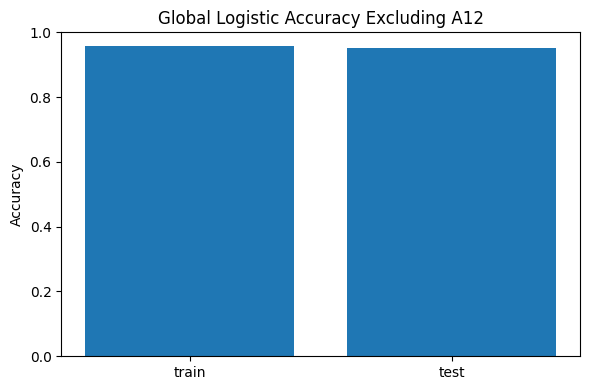

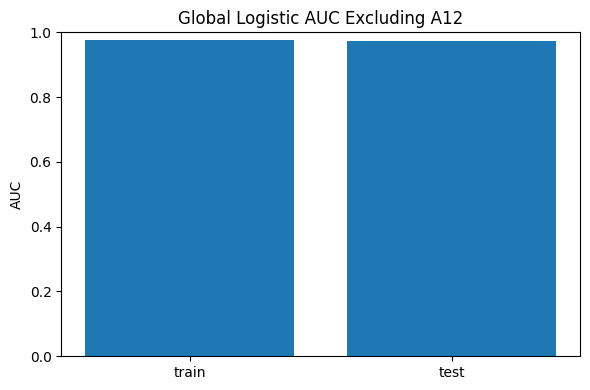

In [15]:
summary_df = pd.DataFrame([
    {
        'split': 'train',
        'accuracy': m_tr['accuracy'],
        'auc': m_tr['auc'],
        'rows': int(is_train.sum()),
    },
    {
        'split': 'test',
        'accuracy': m_te['accuracy'],
        'auc': m_te['auc'],
        'rows': int(is_test.sum()),
    },
])
display(summary_df)

plt.figure(figsize=(6, 4))
plt.bar(summary_df['split'], summary_df['accuracy'])
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Global Logistic Accuracy Excluding A12')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(summary_df['split'], summary_df['auc'])
plt.ylim(0, 1)
plt.ylabel('AUC')
plt.title('Global Logistic AUC Excluding A12')
plt.tight_layout()
plt.show()


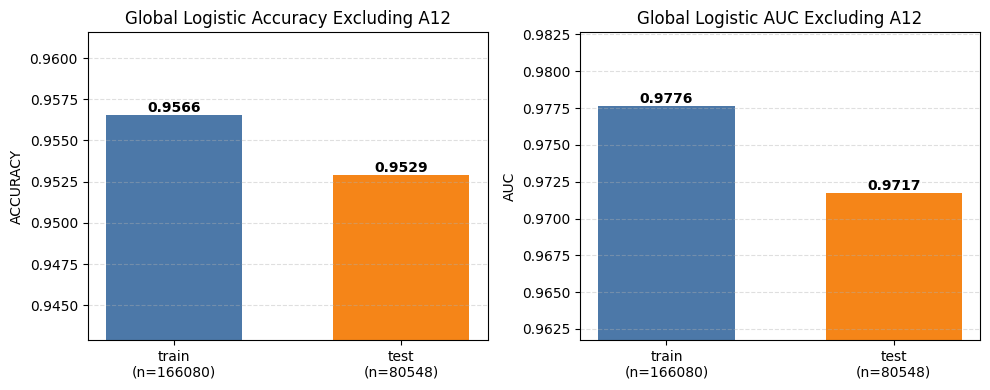

In [16]:
plot_df = summary_df.copy()
plot_df["label"] = plot_df.apply(
    lambda r: f"{r['split']}\n(n={int(r['rows'])})", axis=1
)

metrics = [
    ("accuracy", "Global Logistic Accuracy Excluding A12"),
    ("auc", "Global Logistic AUC Excluding A12"),
]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (metric, title) in zip(axes, metrics):
    vals = plot_df[metric].astype(float).to_numpy()
    labels = plot_df["label"].tolist()

    ymin = max(0.0, vals.min() - 0.01)
    ymax = min(1.0, vals.max() + 0.005)
    if ymax - ymin < 0.01:
        pad = 0.005
        ymin = max(0.0, vals.min() - pad)
        ymax = min(1.0, vals.max() + pad)

    bars = ax.bar(labels, vals, color=["#4C78A8", "#F58518"], width=0.6)
    ax.set_title(title)
    ax.set_ylabel(metric.upper())
    ax.set_ylim(ymin, ymax)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    for bar, v in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            v,
            f"{v:.4f}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
        )

plt.tight_layout()
plt.show()